# Notebook 06 — Reviewer-Closure Experiments

This notebook targets the remaining empirical questions after the first five benchmark notebooks.

**Main goals**
1. Rare-event terminal-error and false-unlock calibration.
2. Extreme information-gap Price-of-Certification convergence.
3. Higher-statistics multihypothesis evaluation for $N=3,5,10$.
4. Stopping-cap / timeout sensitivity.
5. Joint threshold sensitivity in $(\delta,\rho)$.
6. Bootstrap uncertainty for sample-complexity and PoC estimates.
7. Higher-statistics six-class UCI HAR sensing replay with confusion diagnostics.
8. Reviewer-facing claim-status table.

The binary/Bernoulli experiments are theorem-aligned. Multihypothesis and UCI replay experiments are **extensions / stress tests**, not matched-theorem validation.

### Execution modes
- `SMOKE_TEST=1`: very small run used only to verify code.
- normal: moderate run for inspection.
- `FULL_RUN=1`: publication-scale settings (may take substantial time).

In [1]:
from pathlib import Path
import os, sys, math, json, io, zipfile, urllib.request, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == 'notebooks' else HERE
CORE_DIR = None
for cand in [ROOT, HERE, *HERE.parents]:
    if (cand/'src'/'gated_benchmarks.py').exists():
        ROOT = cand
        CORE_DIR = cand/'src'
        break

# STANDALONE_CORE_FALLBACK: when this notebook is downloaded by itself (e.g. Colab),
# create the verified shared core locally so no extra Python file is required.
if CORE_DIR is None:
    CORE_DIR = HERE/'_nb06_lib'
    CORE_DIR.mkdir(exist_ok=True)
    embedded_core = 'from __future__ import annotations\n\nfrom dataclasses import dataclass\nfrom typing import Iterable, Sequence\nimport math\n\nimport numpy as np\nimport pandas as pd\nfrom scipy.optimize import linprog\nfrom scipy.stats import norm\n\nEPS = 1e-12\n\n\ndef _clip_prob(x: float) -> float:\n    return float(np.clip(x, EPS, 1.0 - EPS))\n\n\ndef kl_bernoulli(p: float, q: float) -> float:\n    p = _clip_prob(p)\n    q = _clip_prob(q)\n    return p * math.log(p / q) + (1 - p) * math.log((1 - p) / (1 - q))\n\n\ndef binary_kl(p: float, q: float) -> float:\n    return kl_bernoulli(p, q)\n\n\ndef bernoulli_llr(y: int | np.ndarray, p0: float, p1: float):\n    p0 = _clip_prob(p0)\n    p1 = _clip_prob(p1)\n    y = np.asarray(y)\n    return y * math.log(p0 / p1) + (1 - y) * math.log((1 - p0) / (1 - p1))\n\n\ndef record_envelope(K: Sequence[float]) -> np.ndarray:\n    K = np.asarray(K, dtype=float)\n    if K.ndim != 1 or len(K) == 0:\n        raise ValueError(\'K must be a non-empty one-dimensional sequence.\')\n    return np.maximum.accumulate(K)\n\n\ndef ladder_lower_bound(K: Sequence[float], d: Sequence[float]) -> float:\n    K = np.asarray(K, dtype=float)\n    d = np.asarray(d, dtype=float)\n    if len(K) != len(d):\n        raise ValueError(\'K and d must have the same length.\')\n    if np.any(d <= 0):\n        raise ValueError(\'All KL rates d must be positive.\')\n    if np.any(np.diff(d) < -1e-12):\n        raise ValueError(\'d must be nondecreasing for the closed-form record-envelope bound.\')\n    kb = record_envelope(K)\n    inc = np.diff(np.r_[0.0, kb])\n    return float(np.sum(inc / d))\n\n\ndef solve_ladder_lp(K: Sequence[float], d: Sequence[float]) -> tuple[float, np.ndarray]:\n    K = np.asarray(K, dtype=float)\n    d = np.asarray(d, dtype=float)\n    if len(K) != len(d):\n        raise ValueError(\'K and d must have the same length.\')\n    L = len(K)\n    A = np.zeros((L, L), dtype=float)\n    for ell in range(L):\n        A[ell, : ell + 1] = d[: ell + 1]\n    # scipy linprog uses A_ub x <= b_ub, so negate prefix constraints.\n    res = linprog(np.ones(L), A_ub=-A, b_ub=-K, bounds=[(0, None)] * L, method=\'highs\')\n    if not res.success:\n        raise RuntimeError(f\'LP failed: {res.message}\')\n    return float(res.fun), np.asarray(res.x, dtype=float)\n\n\ndef theoretical_c_gate(d: Sequence[float], rhos_with_endpoints: Sequence[float]) -> float:\n    d = np.asarray(d, dtype=float)\n    r = np.asarray(rhos_with_endpoints, dtype=float)\n    if len(r) != len(d) + 1:\n        raise ValueError(\'rhos_with_endpoints must have length len(d)+1 and include 0 and 1.\')\n    if abs(r[0]) > 1e-12 or abs(r[-1] - 1.0) > 1e-12:\n        raise ValueError(\'rho endpoints must be 0 and 1.\')\n    if np.any(np.diff(r) < -1e-12):\n        raise ValueError(\'rho sequence must be nondecreasing.\')\n    return float(np.sum(np.diff(r) / d))\n\n\ndef price_of_certification(d: Sequence[float], rhos_with_endpoints: Sequence[float]) -> float:\n    d = np.asarray(d, dtype=float)\n    return float(d[-1] * theoretical_c_gate(d, rhos_with_endpoints))\n\n\ndef mean_ci(values: Sequence[float], confidence: float = 0.95) -> tuple[float, float, float]:\n    x = np.asarray(values, dtype=float)\n    x = x[np.isfinite(x)]\n    if len(x) == 0:\n        return math.nan, math.nan, math.nan\n    m = float(np.mean(x))\n    if len(x) == 1:\n        return m, m, m\n    z = norm.ppf((1 + confidence) / 2)\n    se = float(np.std(x, ddof=1) / math.sqrt(len(x)))\n    return m, m - z * se, m + z * se\n\n\ndef wilson_interval(successes: int, n: int, confidence: float = 0.95) -> tuple[float, float]:\n    if n <= 0:\n        return math.nan, math.nan\n    phat = successes / n\n    z = norm.ppf((1 + confidence) / 2)\n    den = 1 + z*z/n\n    center = (phat + z*z/(2*n)) / den\n    half = z * math.sqrt((phat*(1-phat)/n) + z*z/(4*n*n)) / den\n    return max(0.0, center - half), min(1.0, center + half)\n\n\n@dataclass(frozen=True)\nclass BernoulliAction:\n    p0: float\n    p1: float\n    name: str = \'\'\n\n    @property\n    def d0(self) -> float:\n        return kl_bernoulli(self.p0, self.p1)\n\n    @property\n    def d1(self) -> float:\n        return kl_bernoulli(self.p1, self.p0)\n\n    @property\n    def c(self) -> float:\n        vals = [\n            abs(math.log(_clip_prob(self.p0) / _clip_prob(self.p1))),\n            abs(math.log((1-_clip_prob(self.p0)) / (1-_clip_prob(self.p1)))),\n        ]\n        return max(vals)\n\n    def draw(self, rng: np.random.Generator, true_h: int) -> int:\n        p = self.p0 if true_h == 0 else self.p1\n        return int(rng.random() < p)\n\n    def llr(self, y: int) -> float:\n        return float(bernoulli_llr(y, self.p0, self.p1))\n\n\ndef make_alpha_from_rhos(delta: float, rhos: Sequence[float]) -> np.ndarray:\n    rhos = np.asarray(rhos, dtype=float)\n    return np.power(delta, rhos)\n\n\ndef _thresholds_from_alphas(alphas: Sequence[float], delta: float) -> tuple[np.ndarray, float]:\n    alphas = np.asarray(alphas, dtype=float)\n    B = np.log(1.0 / alphas) if len(alphas) else np.array([], dtype=float)\n    A = math.log(1.0 / delta)\n    return B, A\n\n\ndef simulate_binary_ladder(\n    actions: Sequence[BernoulliAction],\n    alphas: Sequence[float],\n    delta: float,\n    true_h: int,\n    n_trials: int = 1000,\n    seed: int = 0,\n    max_steps: int = 100000,\n    policy: str = \'running_max\',\n    fixed_unlock_samples: Sequence[int] | None = None,\n) -> pd.DataFrame:\n    """Simulate binary sequential testing with nested Bernoulli actions.\n\n    Policies:\n      running_max: proposed irreversible certificate using max evidence.\n      current_evidence: level determined by current S_t; may relock.\n      oracle: strongest action from time 0.\n      weak_only: always first action.\n      fixed: unlock levels after fixed sample-count milestones.\n    """\n    if true_h not in (0, 1):\n        raise ValueError(\'true_h must be 0 or 1.\')\n    L = len(actions)\n    if len(alphas) != max(0, L - 1):\n        raise ValueError(\'Need L-1 alpha thresholds.\')\n    B, A = _thresholds_from_alphas(alphas, delta)\n    if len(B) and np.any(np.diff(B) <= 0):\n        # alphas must decrease so thresholds increase.\n        raise ValueError(\'Certification thresholds must be strictly increasing.\')\n    if len(B) and not (B[-1] < A + 1e-12):\n        raise ValueError(\'Last certification threshold must be below terminal threshold.\')\n    if policy == \'fixed\':\n        if fixed_unlock_samples is None:\n            # Reasonable deterministic milestones at the proposed thresholds / d0.\n            fixed_unlock_samples = [max(1, int(math.ceil(B[i] / actions[i].d0))) for i in range(L-1)]\n        if len(fixed_unlock_samples) != L - 1:\n            raise ValueError(\'fixed_unlock_samples must have L-1 entries.\')\n\n    rng = np.random.default_rng(seed)\n    rows = []\n    for trial in range(n_trials):\n        S = 0.0\n        M = 0.0\n        level = L - 1 if policy == \'oracle\' else 0\n        stage_counts = np.zeros(L, dtype=int)\n        crossed = np.zeros(max(0, L - 1), dtype=bool)\n        unlock_times = np.full(max(0, L - 1), np.nan)\n        overshoots = np.full(max(0, L - 1), np.nan)\n        relocks = 0\n        prev_level = level\n        decision = -1\n\n        for t in range(1, max_steps + 1):\n            if policy == \'oracle\':\n                level = L - 1\n            elif policy == \'weak_only\':\n                level = 0\n            elif policy == \'running_max\':\n                level = int(np.searchsorted(B, M, side=\'right\')) if len(B) else 0\n            elif policy == \'current_evidence\':\n                level = int(np.searchsorted(B, S, side=\'right\')) if len(B) else 0\n                if level < prev_level:\n                    relocks += 1\n            elif policy == \'fixed\':\n                level = sum(t - 1 >= n for n in fixed_unlock_samples)\n            else:\n                raise ValueError(f\'Unknown policy {policy}\')\n            level = min(level, L - 1)\n            prev_level = level\n\n            a = actions[level]\n            y = a.draw(rng, true_h)\n            inc = a.llr(y)\n            S += inc\n            M = max(M, S)\n            stage_counts[level] += 1\n\n            # Record first crossing for every threshold reached by running evidence maximum.\n            for k, b in enumerate(B):\n                if (not crossed[k]) and M >= b:\n                    crossed[k] = True\n                    unlock_times[k] = t\n                    overshoots[k] = M - b\n\n            if S >= A:\n                decision = 0\n                break\n            if S <= -A:\n                decision = 1\n                break\n        else:\n            decision = 0 if S >= 0 else 1\n\n        row = {\n            \'trial\': trial,\n            \'true_h\': true_h,\n            \'decision\': decision,\n            \'error\': int(decision != true_h),\n            \'tau\': int(np.sum(stage_counts)),\n            \'final_S\': S,\n            \'max_S\': M,\n            \'max_level_reached\': int(np.max(np.where(stage_counts > 0)[0])) if np.any(stage_counts > 0) else 0,\n            \'false_unlock\': (int(true_h == 1 and np.any(crossed)) if policy == \'running_max\' else\n                             int(true_h == 1 and np.sum(stage_counts[1:]) > 0) if policy in (\'current_evidence\',\'fixed\') else np.nan),\n            \'all_levels_unlocked\': int(np.all(crossed)) if (policy == \'running_max\' and len(crossed)) else np.nan,\n            \'failed_unlock\': (int(true_h == 0 and len(crossed) and not np.all(crossed)) if policy == \'running_max\' else np.nan),\n            \'relocks\': relocks,\n        }\n        for ell in range(L):\n            row[f\'N{ell+1}\'] = int(stage_counts[ell])\n        for k in range(L - 1):\n            row[f\'unlock_t{k+1}\'] = unlock_times[k]\n            row[f\'overshoot{k+1}\'] = overshoots[k]\n        rows.append(row)\n    return pd.DataFrame(rows)\n\n\ndef summarize_binary_runs(df: pd.DataFrame) -> dict:\n    n = len(df)\n    mean_tau, lo_tau, hi_tau = mean_ci(df[\'tau\'])\n    err = int(df[\'error\'].sum())\n    eu_lo, eu_hi = wilson_interval(err, n)\n    fu_series = df[\'false_unlock\'].dropna() if \'false_unlock\' in df else pd.Series(dtype=float)\n    if len(fu_series):\n        false_unlock = int(fu_series.sum())\n        fu_lo, fu_hi = wilson_interval(false_unlock, len(fu_series))\n        fu_rate = false_unlock / len(fu_series)\n    else:\n        fu_lo = fu_hi = fu_rate = math.nan\n    out = {\n        \'n_trials\': n,\n        \'mean_tau\': mean_tau,\n        \'mean_tau_ci_lo\': lo_tau,\n        \'mean_tau_ci_hi\': hi_tau,\n        \'median_tau\': float(df[\'tau\'].median()),\n        \'q95_tau\': float(df[\'tau\'].quantile(0.95)),\n        \'error_rate\': err / n if n else math.nan,\n        \'error_ci_lo\': eu_lo,\n        \'error_ci_hi\': eu_hi,\n        \'false_unlock_rate\': fu_rate,\n        \'false_unlock_ci_lo\': fu_lo,\n        \'false_unlock_ci_hi\': fu_hi,\n        \'failed_unlock_rate\': float(df[\'failed_unlock\'].dropna().mean()) if (\'failed_unlock\' in df and df[\'failed_unlock\'].notna().any()) else math.nan,\n        \'mean_relocks\': float(df[\'relocks\'].mean()) if \'relocks\' in df else math.nan,\n    }\n    for c in [c for c in df.columns if c.startswith(\'N\') and c[1:].isdigit()]:\n        out[f\'mean_{c}\'] = float(df[c].mean())\n    return out\n\n\ndef finite_confidence_two_level(action_w: BernoulliAction, action_s: BernoulliAction, delta: float, alpha: float, beta: float):\n    Kc = binary_kl(1-beta, alpha)\n    Kf = binary_kl(1-delta, delta)\n    dw, ds = action_w.d0, action_s.d0\n    Ld = Kc/dw + max(0.0, Kf-Kc)/ds\n    Bc = math.log(1/alpha)\n    A = math.log(1/delta)\n    Uthr = Bc/dw + max(0.0, A-Bc)/ds\n    Ubd = Uthr + action_w.c/dw + action_s.c/ds\n    return {\n        \'Kc\': Kc, \'Kf\': Kf, \'L_delta\': Ld, \'U_thr\': Uthr, \'U_bd\': Ubd,\n        \'boundary_factor\': Uthr/Ld,\n        \'overshoot_factor\': Ubd/Uthr,\n        \'total_factor\': Ubd/Ld,\n    }\n\n\ndef multihyp_stop_condition(pairwise_llr: np.ndarray, threshold: float) -> tuple[bool, int | None]:\n    pairwise_llr = np.asarray(pairwise_llr, dtype=float)\n    N = pairwise_llr.shape[0]\n    for i in range(N):\n        vals = [pairwise_llr[i, j] for j in range(N) if j != i]\n        if min(vals) >= threshold:\n            return True, i\n    return False, None\n\n\ndef pairwise_llr_from_scores(scores: Sequence[float]) -> np.ndarray:\n    s = np.asarray(scores, dtype=float)\n    return s[:, None] - s[None, :]\n\n\ndef bernoulli_logpmf(y: int, p: float) -> float:\n    p = _clip_prob(p)\n    return math.log(p if y else 1-p)\n\n\ndef generate_multihyp_bernoulli_probs(N: int, mode: str = \'uniform_hardest\') -> np.ndarray:\n    """Return shape (N, 2): weak and strong Bernoulli parameters."""\n    if N < 3:\n        raise ValueError(\'Use N>=3 for multihypothesis benchmarks.\')\n    if mode == \'uniform_hardest\':\n        # H0 at one edge; H1 is nearest under both actions.\n        weak = np.linspace(0.15, 0.85, N)\n        strong = np.linspace(0.05, 0.95, N)\n    elif mode == \'switching\':\n        weak = np.linspace(0.08, 0.92, N)\n        strong = np.linspace(0.92, 0.08, N)\n        weak[0], strong[0] = 0.50, 0.50\n        weak[1], strong[1] = 0.58, 0.90   # hardest at weak\n        weak[2], strong[2] = 0.10, 0.58   # hardest at strong\n        if N > 3:\n            vals = np.linspace(0.15, 0.85, N-3)\n            weak[3:] = vals\n            strong[3:] = vals[::-1]\n    else:\n        raise ValueError(\'mode must be uniform_hardest or switching.\')\n    return np.column_stack([np.clip(weak, 0.02, 0.98), np.clip(strong, 0.02, 0.98)])\n\n\ndef simulate_multihypothesis_gate(\n    probs: np.ndarray,\n    true_h: int,\n    delta: float = 0.05,\n    alpha: float = 0.05,\n    n_trials: int = 500,\n    seed: int = 0,\n    policy: str = \'gated\',\n    max_steps: int = 50000,\n) -> pd.DataFrame:\n    """Exploratory known-simple multihypothesis gate.\n\n    probs[h, a] is Bernoulli parameter for hypothesis h and action a.\n    Action 0 = weak; action 1 = strong. Strong unlocks when H0 beats every\n    alternative by B=log(1/alpha). Final stopping uses pairwise margin\n    A=log((N-1)/delta), giving a simple union-bound-valid multiway rule.\n\n    This is an empirical extension; it is not a matched theorem from the paper.\n    """\n    probs = np.asarray(probs, dtype=float)\n    N, Acount = probs.shape\n    if Acount != 2:\n        raise ValueError(\'This benchmark currently uses exactly two actions.\')\n    if not (0 <= true_h < N):\n        raise ValueError(\'Invalid true_h.\')\n    B = math.log(1/alpha)\n    Astop = math.log((N-1)/delta)\n    rng = np.random.default_rng(seed)\n    rows=[]\n    for tr in range(n_trials):\n        scores=np.zeros(N)\n        unlocked = policy == \'oracle\'\n        unlock_t=np.nan\n        nweak=nstrong=0\n        decision=None\n        for t in range(1, max_steps+1):\n            action = 1 if (unlocked and policy != \'weak_only\') or policy == \'oracle\' else 0\n            ptrue = probs[true_h, action]\n            y = int(rng.random() < ptrue)\n            for h in range(N):\n                scores[h] += bernoulli_logpmf(y, probs[h, action])\n            if action == 0: nweak += 1\n            else: nstrong += 1\n            pair = pairwise_llr_from_scores(scores)\n            if policy == \'gated\' and not unlocked:\n                # Certification that H0 dominates every alternative.\n                if min(pair[0, j] for j in range(1, N)) >= B:\n                    unlocked=True\n                    unlock_t=t\n            stopped, hhat = multihyp_stop_condition(pair, Astop)\n            if stopped:\n                decision=hhat\n                break\n        if decision is None:\n            decision=int(np.argmax(scores))\n        rows.append({\n            \'trial\':tr,\'true_h\':true_h,\'decision\':decision,\n            \'error\':int(decision!=true_h),\'tau\':nweak+nstrong,\n            \'Nweak\':nweak,\'Nstrong\':nstrong,\'unlocked\':int(unlocked),\n            \'false_unlock\':int(true_h!=0 and unlocked),\'unlock_t\':unlock_t,\n        })\n    return pd.DataFrame(rows)\n\n\ndef gaussian_llr(y: float, mu0: float, mu1: float, sigma: float = 1.0) -> float:\n    # Equal-variance Gaussian log likelihood ratio log f0/f1.\n    return ((y-mu1)**2 - (y-mu0)**2) / (2*sigma*sigma)\n\n\ndef gaussian_kl(mu0: float, mu1: float, sigma: float = 1.0) -> float:\n    return (mu0-mu1)**2 / (2*sigma*sigma)\n\n\ndef simulate_gaussian_binary(\n    means_true: Sequence[tuple[float,float]],\n    means_model: Sequence[tuple[float,float]] | None,\n    sigma: float,\n    alphas: Sequence[float],\n    delta: float,\n    true_h: int,\n    n_trials: int = 1000,\n    seed: int = 0,\n    corr: float = 0.0,\n    max_steps: int = 100000,\n) -> pd.DataFrame:\n    """Gaussian stress-test version of the binary ladder.\n\n    `corr>0` introduces AR(1) noise while the likelihood still assumes iid data,\n    intentionally testing robustness outside the theorem assumptions.\n    """\n    mt = np.asarray(means_true, dtype=float)\n    mm = mt.copy() if means_model is None else np.asarray(means_model, dtype=float)\n    L = len(mt)\n    B,A = _thresholds_from_alphas(alphas, delta)\n    rng=np.random.default_rng(seed)\n    rows=[]\n    for tr in range(n_trials):\n        S=M=0.0\n        zprev=0.0\n        stage_counts=np.zeros(L,dtype=int)\n        crossed=np.zeros(L-1,dtype=bool)\n        overs=np.full(L-1,np.nan)\n        dec=None\n        for t in range(1,max_steps+1):\n            level=int(np.searchsorted(B,M,side=\'right\')) if len(B) else 0\n            level=min(level,L-1)\n            eps=rng.normal()\n            z = corr*zprev + math.sqrt(max(0.0,1-corr*corr))*eps\n            zprev=z\n            mu_true=mt[level, true_h]\n            y=mu_true + sigma*z\n            mu0,mu1=mm[level]\n            S += gaussian_llr(y,mu0,mu1,sigma)\n            M=max(M,S)\n            stage_counts[level]+=1\n            for k,b in enumerate(B):\n                if not crossed[k] and M>=b:\n                    crossed[k]=True; overs[k]=M-b\n            if S>=A: dec=0; break\n            if S<=-A: dec=1; break\n        if dec is None: dec=0 if S>=0 else 1\n        row={\'trial\':tr,\'true_h\':true_h,\'decision\':dec,\'error\':int(dec!=true_h),\n             \'tau\':int(stage_counts.sum()),\'false_unlock\':int(true_h==1 and crossed.any()),\n             \'failed_unlock\':int(true_h==0 and len(crossed) and not crossed.all()),\n             \'final_S\':S,\'max_S\':M}\n        for l in range(L): row[f\'N{l+1}\']=int(stage_counts[l])\n        for k in range(L-1): row[f\'overshoot{k+1}\']=overs[k]\n        rows.append(row)\n    return pd.DataFrame(rows)\n'
    (CORE_DIR/'gated_benchmarks.py').write_text(embedded_core, encoding='utf-8')
    ROOT = HERE
    print('Using embedded standalone gated_benchmarks.py fallback')

sys.path.insert(0, str(CORE_DIR))
RESULTS = ROOT/'results'
FIGURES = ROOT/'figures'
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
FULL_RUN = os.getenv('FULL_RUN','0') == '1'
SMOKE_TEST = os.getenv('SMOKE_TEST','0') == '1'
RUN_MODE = 'smoke' if SMOKE_TEST else ('full' if FULL_RUN else 'standard')
print('ROOT =', ROOT)
print('RUN_MODE =', RUN_MODE)


Using embedded standalone gated_benchmarks.py fallback
ROOT = /mnt/data/nb06_standalone_test
RUN_MODE = smoke


In [2]:
from gated_benchmarks import (
    BernoulliAction, simulate_binary_ladder, summarize_binary_runs,
    generate_multihyp_bernoulli_probs, simulate_multihypothesis_gate,
    price_of_certification, theoretical_c_gate, wilson_interval, mean_ci,
)

weak = BernoulliAction(0.7, 0.5, 'weak')
strong = BernoulliAction(0.8, 0.2, 'strong')
OUTPUT_FILES = []

def save_csv(df, name):
    p=RESULTS/name; df.to_csv(p,index=False); OUTPUT_FILES.append(p); return p

def save_fig(fig, name):
    p=FIGURES/name; fig.tight_layout(); fig.savefig(p,dpi=180,bbox_inches='tight'); OUTPUT_FILES.append(p); plt.show(); return p

def bootstrap_ci(values, stat=np.mean, B=None, seed=0, confidence=.95):
    """Percentile bootstrap CI used for reviewer-facing uncertainty summaries."""
    x=np.asarray(values,dtype=float); x=x[np.isfinite(x)]
    if len(x)==0: return (np.nan,np.nan,np.nan)
    B = B or (100 if SMOKE_TEST else (1000 if not FULL_RUN else 3000))
    rng=np.random.default_rng(seed)
    estimates=np.empty(B)
    for b in range(B): estimates[b]=stat(rng.choice(x,size=len(x),replace=True))
    a=(1-confidence)/2
    return float(stat(x)), float(np.quantile(estimates,a)), float(np.quantile(estimates,1-a))

print('KL weak H0:',weak.d0,'strong H0:',strong.d0)

KL weak H0: 0.08228287850505184 strong H0: 0.8317766166719343


## 1. Rare-event calibration
We separately test terminal decision error and the anytime false-unlock event. False-unlock calibration is simulated directly under $H_1$ to avoid conflating the certification boundary with a terminal stopping boundary.

,delta,true_h,n_trials,error_rate,error_ci_lo,error_ci_hi,mean_tau,cap_hit_rate
0,0.010,0,80,0.0000,0.000000,0.045818,25.7500,0.0
1,0.010,1,80,0.0375,0.012835,0.104547,50.6625,0.0
2,0.001,0,80,0.0000,0.000000,0.045818,49.1375,0.0
3,0.001,1,80,0.0000,0.000000,0.045818,80.5625,0.0


,alpha,n_trials,horizon,observed,ci_lo,ci_hi,hits,mean_hit_time
0,0.010,300,800,0.013333,0.005197,0.033776,4,34.75
1,0.001,300,800,0.003333,0.000589,0.018637,1,71.00


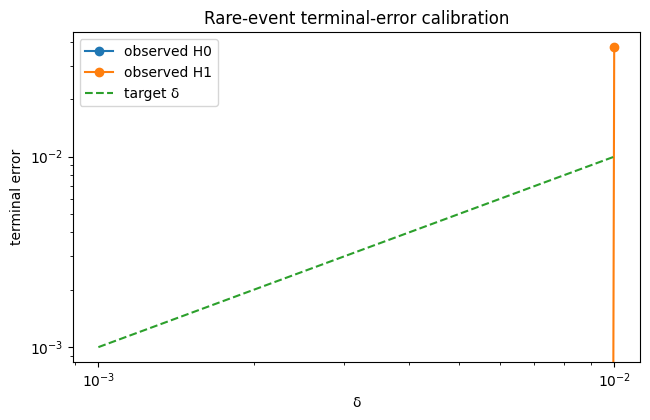

PosixPath('/mnt/data/nb06_standalone_test/figures/closure_rare_terminal_error.png')

In [3]:
def direct_false_unlock(alpha, n_trials, horizon=4000, seed=0, action=weak):
    """Estimate P_1(sup_{t<=horizon} S_t >= log(1/alpha))."""
    rng=np.random.default_rng(seed); B=math.log(1/alpha); hits=0; hit_times=[]
    # Chunk trials to keep memory small while vectorizing time evolution.
    chunk=20000 if n_trials>20000 else n_trials
    done=0
    while done<n_trials:
        m=min(chunk,n_trials-done); S=np.zeros(m); alive=np.ones(m,dtype=bool); first=np.full(m,-1,dtype=int)
        for t in range(1,horizon+1):
            idx=np.flatnonzero(alive)
            if len(idx)==0: break
            y=(rng.random(len(idx)) < action.p1).astype(int)
            inc=np.where(y, math.log(action.p0/action.p1), math.log((1-action.p0)/(1-action.p1)))
            S[idx]+=inc
            crossed=S[idx]>=B
            if np.any(crossed):
                cidx=idx[crossed]; first[cidx]=t; alive[cidx]=False
        hits += int(np.sum(first>=0)); hit_times.extend(first[first>=0].tolist()); done += m
    lo,hi=wilson_interval(hits,n_trials)
    return {'alpha':alpha,'n_trials':n_trials,'horizon':horizon,'observed':hits/n_trials,
            'ci_lo':lo,'ci_hi':hi,'hits':hits,'mean_hit_time':float(np.mean(hit_times)) if hit_times else np.nan}

def rare_event_calibration():
    # Terminal error: alpha=sqrt(delta) keeps certification threshold below final threshold.
    deltas=[1e-2,1e-3,1e-4] if not FULL_RUN else [1e-2,1e-3,1e-4,1e-5]
    if SMOKE_TEST: deltas=[1e-2,1e-3]
    n_term=80 if SMOKE_TEST else (2500 if not FULL_RUN else 20000)
    terminal=[]
    for j,delta in enumerate(deltas):
        alpha=delta**0.5
        for h in [0,1]:
            df=simulate_binary_ladder([weak,strong],[alpha],delta,h,n_trials=n_term,seed=1000+100*j+h,
                                      max_steps=(10000 if FULL_RUN else 5000),policy='running_max')
            s=summarize_binary_runs(df)
            terminal.append({'delta':delta,'alpha':alpha,'true_h':h,**s,
                             'cap_hit_rate':float((df.tau >= (10000 if FULL_RUN else 5000)).mean())})
    terminal=pd.DataFrame(terminal)

    alphas=[1e-2,1e-3,1e-4] if not FULL_RUN else [1e-2,1e-3,1e-4,1e-5]
    if SMOKE_TEST: alphas=[1e-2,1e-3]
    n_false=300 if SMOKE_TEST else (10000 if not FULL_RUN else 200000)
    false=pd.DataFrame([direct_false_unlock(a,n_false,horizon=(800 if SMOKE_TEST else 5000),seed=2200+i)
                        for i,a in enumerate(alphas)])
    return terminal,false

rare_terminal, rare_false = rare_event_calibration()
display(rare_terminal[['delta','true_h','n_trials','error_rate','error_ci_lo','error_ci_hi','mean_tau','cap_hit_rate']])
display(rare_false)
save_csv(rare_terminal,'closure_rare_terminal_error.csv')
save_csv(rare_false,'closure_rare_false_unlock.csv')

fig,ax=plt.subplots(figsize=(6.6,4.3))
for h in [0,1]:
    q=rare_terminal[rare_terminal.true_h==h]
    ax.plot(q.delta,q.error_rate,marker='o',label=f'observed H{h}')
ax.plot(sorted(rare_terminal.delta.unique()),sorted(rare_terminal.delta.unique()),linestyle='--',label='target δ')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('δ'); ax.set_ylabel('terminal error'); ax.legend(); ax.set_title('Rare-event terminal-error calibration')
save_fig(fig,'closure_rare_terminal_error.png')

## 2. Extreme Price-of-Certification convergence
This directly revisits the previously difficult large-information-gap regime and asks whether the empirical gated/oracle ratio moves toward the asymptotic PoC as $\delta\downarrow0$.

,delta,rho,n_trials,theory_poc,empirical_poc,poc_ci_lo,poc_ci_hi,gated_mean_tau,oracle_mean_tau,gated_cap_hit
0,0.10,0.5,40,27.864244,13.100000,10.862500,15.251250,13.100,1.0,0.0
1,0.01,0.5,40,27.864244,13.940476,10.681395,20.292506,29.275,2.1,0.0


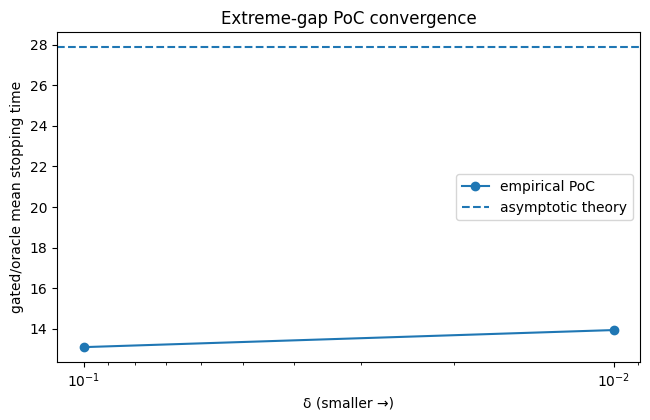

PosixPath('/mnt/data/nb06_standalone_test/figures/closure_extreme_poc_convergence.png')

In [4]:
def extreme_poc_convergence():
    w=BernoulliAction(.7,.5,'weak'); s=BernoulliAction(.99,.01,'strong'); rho=.5
    deltas=[1e-1,3e-2,1e-2,3e-3] if not FULL_RUN else [1e-1,3e-2,1e-2,3e-3,1e-3,3e-4,1e-4,1e-5]
    if SMOKE_TEST: deltas=[.1,.01]
    n=40 if SMOKE_TEST else (800 if not FULL_RUN else 4000)
    theory=price_of_certification([w.d0,s.d0],[0,rho,1])
    rows=[]
    for i,dlt in enumerate(deltas):
        alpha=dlt**rho
        gd=simulate_binary_ladder([w,s],[alpha],dlt,0,n_trials=n,seed=3100+i,policy='running_max',max_steps=20000)
        od=simulate_binary_ladder([w,s],[alpha],dlt,0,n_trials=n,seed=4100+i,policy='oracle',max_steps=20000)
        gmean,glo,ghi=bootstrap_ci(gd.tau,seed=10+i); omean,olo,ohi=bootstrap_ci(od.tau,seed=20+i)
        # Paired-bootstrap style ratio using independent resamples.
        rng=np.random.default_rng(5000+i); B=100 if SMOKE_TEST else (1000 if not FULL_RUN else 3000); ratios=[]
        ga=gd.tau.to_numpy(); oa=od.tau.to_numpy()
        for _ in range(B): ratios.append(rng.choice(ga,len(ga),True).mean()/rng.choice(oa,len(oa),True).mean())
        rows.append({'delta':dlt,'rho':rho,'n_trials':n,'theory_poc':theory,'empirical_poc':gmean/omean,
                     'poc_ci_lo':float(np.quantile(ratios,.025)),'poc_ci_hi':float(np.quantile(ratios,.975)),
                     'gated_mean_tau':gmean,'oracle_mean_tau':omean,'gated_cap_hit':float((gd.tau>=20000).mean())})
    return pd.DataFrame(rows)

extreme_poc=extreme_poc_convergence(); display(extreme_poc); save_csv(extreme_poc,'closure_extreme_poc_convergence.csv')
fig,ax=plt.subplots(figsize=(6.6,4.3)); ax.plot(extreme_poc.delta,extreme_poc.empirical_poc,marker='o',label='empirical PoC'); ax.axhline(extreme_poc.theory_poc.iloc[0],linestyle='--',label='asymptotic theory'); ax.set_xscale('log'); ax.invert_xaxis(); ax.set_xlabel('δ (smaller →)'); ax.set_ylabel('gated/oracle mean stopping time'); ax.legend(); ax.set_title('Extreme-gap PoC convergence'); save_fig(fig,'closure_extreme_poc_convergence.png')

## 3. Higher-statistics multihypothesis benchmark
We test $N\in\{3,5,10\}$ under uniformly-hardest and hardest-alternative-switching constructions. This is empirical extension evidence, not a matched theorem claim.

,N,mode,policy,true_h,n_trials,mean_tau,mean_tau_ci_lo,mean_tau_ci_hi,error_rate,error_ci_lo,error_ci_hi,false_unlock_rate,cap_hit_rate
0,3,uniform_hardest,gated,0,8,14.000,7.771875,21.500000,0.000,0.000000,0.324408,0.0,0.0
1,3,uniform_hardest,gated,1,8,23.875,15.725000,34.250000,0.000,0.000000,0.324408,0.0,0.0
2,3,uniform_hardest,gated,2,8,17.625,13.434375,21.631250,0.000,0.000000,0.324408,0.0,0.0
3,3,uniform_hardest,oracle,0,8,7.875,6.625000,9.453125,0.000,0.000000,0.324408,0.0,0.0
4,3,uniform_hardest,oracle,1,8,7.625,6.434375,9.125000,0.000,0.000000,0.324408,1.0,0.0
5,3,uniform_hardest,oracle,2,8,6.625,6.000000,7.875000,0.000,0.000000,0.324408,1.0,0.0
6,3,uniform_hardest,weak_only,0,8,12.750,9.553125,17.000000,0.000,0.000000,0.324408,0.0,0.0
7,3,uniform_hardest,weak_only,1,8,22.375,15.106250,28.696875,0.125,0.022417,0.470888,0.0,0.0
8,3,uniform_hardest,weak_only,2,8,12.625,8.000000,16.703125,0.000,0.000000,0.324408,0.0,0.0
9,3,switching,gated,0,8,243.375,156.075000,437.159375,0.000,0.000000,0.324408,0.0,0.0


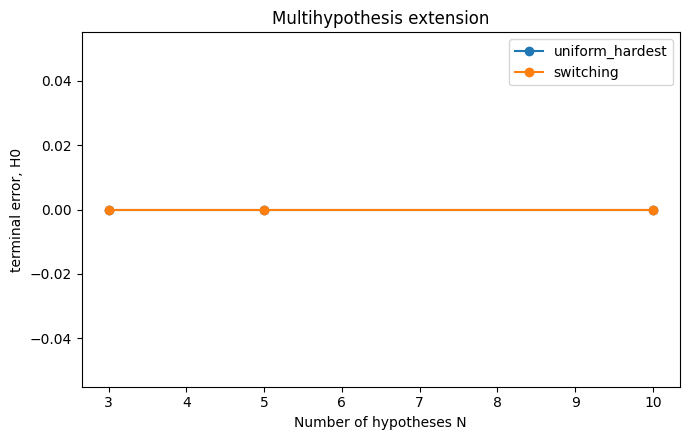

PosixPath('/mnt/data/nb06_standalone_test/figures/closure_multihypothesis_error.png')

In [5]:
def multihypothesis_high_stats():
    Ns=[3,5,10]; modes=['uniform_hardest','switching']; policies=['gated','oracle','weak_only']
    n=8 if SMOKE_TEST else (120 if not FULL_RUN else 600)
    rows=[]; conf_rows=[]
    for N in Ns:
        for mode in modes:
            probs=generate_multihyp_bernoulli_probs(N,mode)
            true_set=range(N) if (FULL_RUN or SMOKE_TEST) else [0,1,min(2,N-1)]
            for pidx,policy in enumerate(policies):
                for h in true_set:
                    df=simulate_multihypothesis_gate(probs,h,delta=.05,alpha=.05,n_trials=n,
                                                     seed=6000+N*100+pidx*20+h+(0 if mode=='uniform_hardest' else 500),
                                                     policy=policy,max_steps=(8000 if FULL_RUN else 3000))
                    m,lo,hi=bootstrap_ci(df.tau,seed=N*100+h+pidx)
                    e=int(df.error.sum()); elo,ehi=wilson_interval(e,len(df))
                    rows.append({'N':N,'mode':mode,'policy':policy,'true_h':h,'n_trials':n,'mean_tau':m,'mean_tau_ci_lo':lo,'mean_tau_ci_hi':hi,
                                 'error_rate':e/len(df),'error_ci_lo':elo,'error_ci_hi':ehi,'false_unlock_rate':df.false_unlock.mean(),
                                 'cap_hit_rate':float((df.tau >= (8000 if FULL_RUN else 3000)).mean())})
                    if policy=='gated':
                        ct=pd.crosstab(df.true_h,df.decision)
                        for dec,count in ct.loc[h].items(): conf_rows.append({'N':N,'mode':mode,'true_h':h,'decision':int(dec),'count':int(count)})
    return pd.DataFrame(rows),pd.DataFrame(conf_rows)

mh, mh_conf = multihypothesis_high_stats(); display(mh.head(18)); save_csv(mh,'closure_multihypothesis_high_stats.csv'); save_csv(mh_conf,'closure_multihypothesis_confusion.csv')
fig,ax=plt.subplots(figsize=(7,4.5)); q=mh[(mh.policy=='gated') & (mh.true_h==0)];
for mode in q['mode'].unique():
    z=q[q['mode']==mode]; ax.plot(z.N,z.error_rate,marker='o',label=mode)
ax.set_xlabel('Number of hypotheses N'); ax.set_ylabel('terminal error, H0'); ax.set_title('Multihypothesis extension'); ax.legend(); save_fig(fig,'closure_multihypothesis_error.png')

## 4. Stopping-cap sensitivity
A sequential result should not depend on an arbitrary `max_steps`. We explicitly measure both error and cap-hit rate as the truncation horizon increases.

,max_steps,true_h,mean_tau,error_rate,cap_hit_rate
0,50,0,26.0750,0.0250,0.100
1,50,1,37.6625,0.0250,0.325
2,250,0,32.1375,0.0000,0.000
3,250,1,47.5250,0.0125,0.000
4,1000,0,30.1750,0.0000,0.000
5,1000,1,47.9875,0.0000,0.000


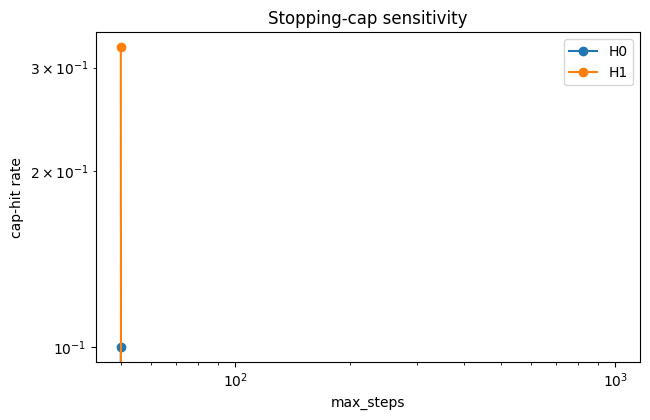

PosixPath('/mnt/data/nb06_standalone_test/figures/closure_stopping_cap_sensitivity.png')

In [6]:
def stopping_cap_sensitivity():
    caps=[50,100,250,500,1000] if not FULL_RUN else [50,100,250,500,1000,2500,5000,10000]
    if SMOKE_TEST: caps=[50,250,1000]
    n=80 if SMOKE_TEST else (1500 if not FULL_RUN else 5000); delta=.01; alpha=.1; rows=[]
    for i,cap in enumerate(caps):
        for h in [0,1]:
            df=simulate_binary_ladder([weak,strong],[alpha],delta,h,n_trials=n,seed=7200+i*10+h,policy='running_max',max_steps=cap)
            s=summarize_binary_runs(df); rows.append({'max_steps':cap,'true_h':h,**s,'cap_hit_rate':float((df.tau>=cap).mean())})
    return pd.DataFrame(rows)

cap_df=stopping_cap_sensitivity(); display(cap_df[['max_steps','true_h','mean_tau','error_rate','cap_hit_rate']]); save_csv(cap_df,'closure_stopping_cap_sensitivity.csv')
fig,ax=plt.subplots(figsize=(6.6,4.3));
for h in [0,1]:
    q=cap_df[cap_df.true_h==h]; ax.plot(q.max_steps,q.cap_hit_rate,marker='o',label=f'H{h}')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('max_steps'); ax.set_ylabel('cap-hit rate'); ax.set_title('Stopping-cap sensitivity'); ax.legend(); save_fig(fig,'closure_stopping_cap_sensitivity.png')

## 5. Joint threshold sensitivity
We sweep the certification fraction $ho$ and final confidence $\delta$, measuring sample complexity, false unlock, terminal error and empirical PoC.

,delta,rho,alpha,true_h,n_trials,mean_tau,mean_tau_ci_lo,mean_tau_ci_hi,median_tau,q95_tau,error_rate,error_ci_lo,error_ci_hi,false_unlock_rate,false_unlock_ci_lo,false_unlock_ci_hi,failed_unlock_rate,mean_relocks,mean_N1,mean_N2,empirical_poc,theory_poc
0,0.01,0.3,0.251189,0,50,21.70,17.402193,25.997807,17.0,48.05,0.0,6.938894e-18,0.071348,0.00,6.938894e-18,0.071348,0.0,0.0,16.58,5.12,3.064972,3.732623
1,0.01,0.3,0.251189,1,50,47.58,38.365303,56.794697,39.0,82.00,0.0,6.938894e-18,0.071348,0.06,2.061497e-02,0.162171,0.0,0.0,47.12,0.46,NaN,NaN
2,0.01,0.7,0.039811,0,50,37.84,31.376457,44.303543,32.5,89.50,0.0,6.938894e-18,0.071348,0.00,6.938894e-18,0.071348,0.0,0.0,36.36,1.48,5.284916,7.376121
3,0.01,0.7,0.039811,1,50,50.86,42.194078,59.525922,41.0,110.65,0.0,6.938894e-18,0.071348,0.08,3.154951e-02,0.188382,0.0,0.0,50.10,0.76,NaN,NaN


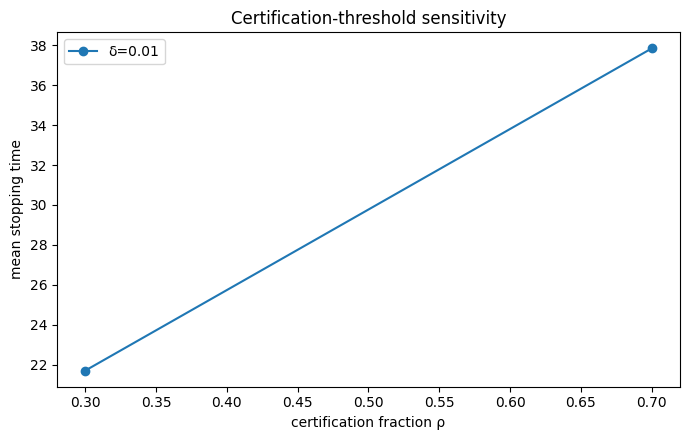

PosixPath('/mnt/data/nb06_standalone_test/figures/closure_threshold_sensitivity.png')

In [7]:
def threshold_sensitivity():
    rhos=[.1,.3,.5,.7,.9]; deltas=[1e-2,1e-3] if not FULL_RUN else [1e-2,3e-3,1e-3,3e-4]
    if SMOKE_TEST: rhos=[.3,.7]; deltas=[1e-2]
    n=50 if SMOKE_TEST else (800 if not FULL_RUN else 3000); rows=[]
    for i,dlt in enumerate(deltas):
        for j,rho in enumerate(rhos):
            alpha=dlt**rho
            for h in [0,1]:
                gd=simulate_binary_ladder([weak,strong],[alpha],dlt,h,n_trials=n,seed=8000+i*100+j*10+h,policy='running_max',max_steps=10000)
                s=summarize_binary_runs(gd)
                if h==0:
                    od=simulate_binary_ladder([weak,strong],[alpha],dlt,0,n_trials=n,seed=9000+i*100+j,policy='oracle',max_steps=10000)
                    emp_poc=gd.tau.mean()/od.tau.mean(); th_poc=price_of_certification([weak.d0,strong.d0],[0,rho,1])
                else: emp_poc=th_poc=np.nan
                rows.append({'delta':dlt,'rho':rho,'alpha':alpha,'true_h':h,**s,'empirical_poc':emp_poc,'theory_poc':th_poc})
    return pd.DataFrame(rows)

thr=threshold_sensitivity(); display(thr.head(12)); save_csv(thr,'closure_threshold_sensitivity.csv')
fig,ax=plt.subplots(figsize=(7,4.5)); q=thr[thr.true_h==0]
for dlt in q.delta.unique():
    z=q[q.delta==dlt]; ax.plot(z.rho,z.mean_tau,marker='o',label=f'δ={dlt:g}')
ax.set_xlabel('certification fraction ρ'); ax.set_ylabel('mean stopping time'); ax.set_title('Certification-threshold sensitivity'); ax.legend(); save_fig(fig,'closure_threshold_sensitivity.png')

## 6. Higher-statistics six-class UCI HAR replay
Weak sensing uses accelerometer-derived features; strong sensing adds gyroscope-derived features. This is an **offline sensing replay**, not a physical safety validation.

mock smoke-test data (900, 60) (360, 60)


,source,policy,true_class,n,error_rate,mean_tau,mean_Nweak,mean_Nstrong,cap_hit_rate
0,mock smoke-test data,gated,1,4,0.75,55.25,38.25,17.00,0.00
1,mock smoke-test data,gated,2,4,0.00,81.50,67.25,14.25,0.00
2,mock smoke-test data,gated,3,4,0.25,78.50,66.25,12.25,0.00
3,mock smoke-test data,gated,4,4,0.75,65.25,57.25,8.00,0.00
4,mock smoke-test data,gated,5,4,0.00,76.75,65.00,11.75,0.00
5,mock smoke-test data,gated,6,4,0.00,75.25,63.00,12.25,0.00
6,mock smoke-test data,oracle,1,4,0.25,14.75,0.00,14.75,0.00
7,mock smoke-test data,oracle,2,4,0.00,17.75,0.00,17.75,0.00
8,mock smoke-test data,oracle,3,4,0.25,43.50,0.00,43.50,0.00
9,mock smoke-test data,oracle,4,4,0.50,25.25,0.00,25.25,0.00


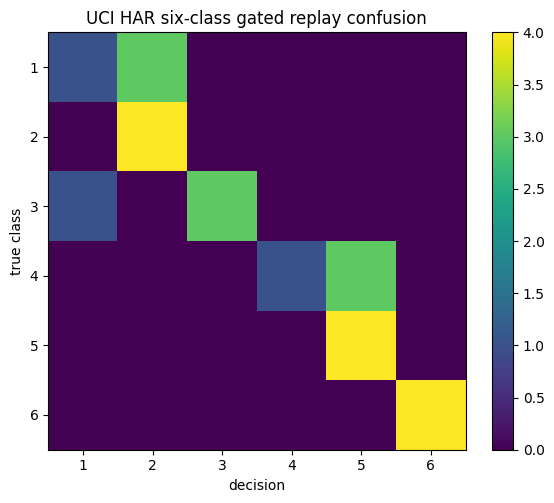

PosixPath('/mnt/data/nb06_standalone_test/figures/closure_uci_har_confusion.png')

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB

UCI_URL='https://archive.ics.uci.edu/static/public/240/human%2Bactivity%2Brecognition%2Busing%2Bsmartphones.zip'

def make_mock_har(seed=0,n_train=900,n_test=360,n_features=60,n_classes=6):
    rng=np.random.default_rng(seed); half=n_features//2
    names=[(f'tBodyAcc-mean()-X{j}' if j<half else f'tBodyGyro-mean()-X{j}') for j in range(n_features)]
    da=rng.normal(size=half); da/=np.linalg.norm(da); dg=rng.normal(size=n_features-half); dg/=np.linalg.norm(dg)
    coords=np.linspace(-1,1,n_classes); means=np.zeros((n_classes,n_features))
    for k,c in enumerate(coords): means[k,:half]=.35*c*da; means[k,half:]=1.5*c*dg
    def sample(n):
        y=rng.integers(1,n_classes+1,n); X=np.vstack([rng.normal(means[k-1],.85) for k in y]); return pd.DataFrame(X,columns=names),pd.Series(y)
    Xtr,ytr=sample(n_train); Xte,yte=sample(n_test); return Xtr,ytr,Xte,yte

def load_uci_har():
    if SMOKE_TEST: return (*make_mock_har(), 'mock smoke-test data')
    cache=RESULTS/'uci_har.zip'
    if not cache.exists(): urllib.request.urlretrieve(UCI_URL,cache)
    with zipfile.ZipFile(cache) as z:
        prefix='UCI HAR Dataset/'
        feat=pd.read_csv(z.open(prefix+'features.txt'),sep=r'\s+',header=None,names=['id','name'])['name'].astype(str).tolist()
        feat=[f'{name}__{i}' for i,name in enumerate(feat)]
        Xtr=pd.read_csv(z.open(prefix+'train/X_train.txt'),sep=r'\s+',header=None,names=feat); ytr=pd.read_csv(z.open(prefix+'train/y_train.txt'),header=None)[0]
        Xte=pd.read_csv(z.open(prefix+'test/X_test.txt'),sep=r'\s+',header=None,names=feat); yte=pd.read_csv(z.open(prefix+'test/y_test.txt'),header=None)[0]
    return Xtr,ytr,Xte,yte,'UCI HAR real data'

try:
    Xtr,ytr,Xte,yte,HAR_SOURCE=load_uci_har()
except Exception as e:
    warnings.warn(f'UCI download failed: {e}; using mock fallback only for code validation.')
    Xtr,ytr,Xte,yte=make_mock_har(); HAR_SOURCE='mock fallback — NOT REPORTABLE'
print(HAR_SOURCE, Xtr.shape, Xte.shape)

weak_cols=[c for c in Xtr.columns if 'Acc' in c and 'Gyro' not in c]
strong_cols=[c for c in Xtr.columns if ('Acc' in c or 'Gyro' in c)]
if len(weak_cols)<5: weak_cols=list(Xtr.columns[:max(5,Xtr.shape[1]//2)])
if len(strong_cols)<=len(weak_cols): strong_cols=list(Xtr.columns)

def fit_density(X,y,cols,n_components):
    sc=StandardScaler().fit(X[cols]); Z=sc.transform(X[cols]); nc=min(n_components,Z.shape[1],max(2,Z.shape[0]-1)); pca=PCA(n_components=nc,random_state=0).fit(Z); Q=pca.transform(Z); g=GaussianNB(var_smoothing=1e-6).fit(Q,y); return sc,pca,g,cols

def batch_ll(model,X):
    sc,pca,g,cols=model; Q=pca.transform(sc.transform(X[cols])); var=g.var_[None,:,:]; th=g.theta_[None,:,:]; return -0.5*np.sum(np.log(2*np.pi*var)+(Q[:,None,:]-th)**2/var,axis=2)

wm=fit_density(Xtr,ytr,weak_cols,5); sm=fit_density(Xtr,ytr,strong_cols,12)
LLW=batch_ll(wm,Xte); LLS=batch_ll(sm,Xte); classes=list(wm[2].classes_); pools={h:np.flatnonzero(yte.to_numpy()==h) for h in classes}

def sixclass_replay_high_stats(policy='gated',delta=.1,cert_margin=2.0,n_trials_per_class=100,seed=0,max_steps=300):
    rng=np.random.default_rng(seed); A=math.log((len(classes)-1)/delta); rows=[]
    for h in classes:
        for tr in range(n_trials_per_class):
            scores=np.zeros(len(classes)); unlocked=(policy=='oracle'); nw=ns=0; dec=None
            for t in range(1,max_steps+1):
                idx=int(rng.choice(pools[h])); use_strong=(policy=='oracle') or (policy=='gated' and unlocked)
                ll=LLS[idx] if use_strong else LLW[idx]; scores+=ll
                if use_strong: ns+=1
                else: nw+=1
                order=np.argsort(scores)[::-1]; margin=scores[order[0]]-scores[order[1]]
                if policy=='gated' and not unlocked and margin>=cert_margin: unlocked=True
                if margin>=A: dec=classes[order[0]]; break
            if dec is None: dec=classes[int(np.argmax(scores))]
            rows.append({'source':HAR_SOURCE,'policy':policy,'true_class':h,'decision':dec,'error':int(dec!=h),'tau':nw+ns,'Nweak':nw,'Nstrong':ns,'unlocked':int(unlocked),'cap_hit':int(nw+ns>=max_steps)})
    return pd.DataFrame(rows)

n_har=4 if SMOKE_TEST else (100 if not FULL_RUN else 500)
har_runs=pd.concat([sixclass_replay_high_stats(p,n_trials_per_class=n_har,seed=10000+i) for i,p in enumerate(['gated','oracle','weak_only'])],ignore_index=True)
summary=har_runs.groupby(['source','policy','true_class']).agg(n=('error','size'),error_rate=('error','mean'),mean_tau=('tau','mean'),mean_Nweak=('Nweak','mean'),mean_Nstrong=('Nstrong','mean'),cap_hit_rate=('cap_hit','mean')).reset_index()
display(summary.head(18)); save_csv(har_runs,'closure_uci_har_sixclass_trials.csv'); save_csv(summary,'closure_uci_har_sixclass_summary.csv')

# Confusion matrix for gated replay.
g=har_runs[har_runs.policy=='gated']; cm=pd.crosstab(g.true_class,g.decision).reindex(index=classes,columns=classes,fill_value=0)
cm_path=RESULTS/'closure_uci_har_gated_confusion.csv'; cm.to_csv(cm_path); OUTPUT_FILES.append(cm_path)
fig,ax=plt.subplots(figsize=(6,5)); im=ax.imshow(cm.to_numpy()); ax.set_xticks(range(len(classes)),classes); ax.set_yticks(range(len(classes)),classes); ax.set_xlabel('decision'); ax.set_ylabel('true class'); ax.set_title('UCI HAR six-class gated replay confusion'); fig.colorbar(im,ax=ax); save_fig(fig,'closure_uci_har_confusion.png')

## 7. Reviewer-facing closure table
The table below records what each new experiment is intended to resolve. In smoke mode, statuses are only execution diagnostics and must not be copied into the paper.

In [9]:
def make_claim_table():
    rows=[]
    # Rare terminal calibration: conservative criterion = all cap-hit rates zero and target lies inside/below upper CI reasonably.
    rows.append({'claim':'Terminal-error calibration','experiment':'rare_event_calibration','mode':RUN_MODE,
                 'key_result':f"max observed error={rare_terminal.error_rate.max():.4g}",
                 'status':'reportable after full run' if FULL_RUN else 'needs full run'})
    rows.append({'claim':'Anytime false-unlock control','experiment':'rare_event_calibration','mode':RUN_MODE,
                 'key_result':f"max observed/target={(rare_false.observed/rare_false.alpha).max():.3f}",
                 'status':'reportable after full run' if FULL_RUN else 'needs full run'})
    last=extreme_poc.sort_values('delta').iloc[0]
    rows.append({'claim':'Extreme-gap PoC approaches theory','experiment':'extreme_poc_convergence','mode':RUN_MODE,
                 'key_result':f"smallest-delta empirical={last.empirical_poc:.3f}, theory={last.theory_poc:.3f}",
                 'status':'evaluate convergence'})
    rows.append({'claim':'Multihypothesis extension behavior','experiment':'multihypothesis_high_stats','mode':RUN_MODE,
                 'key_result':f"max gated H0 error={mh[(mh.policy=='gated')&(mh.true_h==0)].error_rate.max():.3f}",
                 'status':'exploratory only'})
    rows.append({'claim':'No stopping-cap artifact','experiment':'stopping_cap_sensitivity','mode':RUN_MODE,
                 'key_result':f"min cap-hit={cap_df.cap_hit_rate.min():.4g}",
                 'status':'reportable after full run' if FULL_RUN else 'needs full run'})
    rows.append({'claim':'Six-class external replay','experiment':'sixclass_replay_high_stats','mode':RUN_MODE,
                 'key_result':f"gated macro error={g.error.mean():.3f}",
                 'status':'external extension; inspect per-class failures'})
    return pd.DataFrame(rows)

claim_status=make_claim_table(); display(claim_status); save_csv(claim_status,'closure_claim_status.csv')
summary_json=RESULTS/'closure_run_summary.json'; summary_json.write_text(json.dumps({'run_mode':RUN_MODE,'har_source':HAR_SOURCE,'output_files':[str(p.name) for p in OUTPUT_FILES]},indent=2)); OUTPUT_FILES.append(summary_json)

,claim,experiment,mode,key_result,status
0,Terminal-error calibration,rare_event_calibration,smoke,max observed error=0.0375,needs full run
1,Anytime false-unlock control,rare_event_calibration,smoke,max observed/target=3.333,needs full run
2,Extreme-gap PoC approaches theory,extreme_poc_convergence,smoke,"smallest-delta empirical=13.940, theory=27.864",evaluate convergence
3,Multihypothesis extension behavior,multihypothesis_high_stats,smoke,max gated H0 error=0.000,exploratory only
4,No stopping-cap artifact,stopping_cap_sensitivity,smoke,min cap-hit=0,needs full run
5,Six-class external replay,sixclass_replay_high_stats,smoke,gated macro error=0.292,external extension; inspect per-class failures


## 8. Download all results
The final cell creates one ZIP containing every result/figure produced by this notebook and automatically downloads it when running in Google Colab.

In [10]:
# FINAL EXPORT CELL — packages all Notebook 06 outputs.
archive = ROOT/'reviewer_closure_results.zip'
with zipfile.ZipFile(archive,'w',compression=zipfile.ZIP_DEFLATED) as z:
    for p in sorted(set(OUTPUT_FILES)):
        if p.exists():
            arc = f"figures/{p.name}" if p.parent == FIGURES else f"results/{p.name}"
            z.write(p,arcname=arc)
    # Include protocol and experiment matrix for context when present.
    for meta in [ROOT/'EXPERIMENTAL_PROTOCOL.md', ROOT/'EXPERIMENT_MATRIX.csv']:
        if meta.exists(): z.write(meta,arcname=meta.name)
print(f'Created: {archive}')
print(f'ZIP size: {archive.stat().st_size/1024:.1f} KB')
with zipfile.ZipFile(archive) as z:
    print('Files in ZIP:', len(z.namelist()))
    for name in z.namelist(): print(' -',name)

try:
    from google.colab import files
    files.download(str(archive))
except Exception:
    print('Not running in Google Colab. Download manually from:', archive)

Created: /mnt/data/nb06_standalone_test/reviewer_closure_results.zip
ZIP size: 227.0 KB
Files in ZIP: 18
 - figures/closure_extreme_poc_convergence.png
 - figures/closure_multihypothesis_error.png
 - figures/closure_rare_terminal_error.png
 - figures/closure_stopping_cap_sensitivity.png
 - figures/closure_threshold_sensitivity.png
 - figures/closure_uci_har_confusion.png
 - results/closure_claim_status.csv
 - results/closure_extreme_poc_convergence.csv
 - results/closure_multihypothesis_confusion.csv
 - results/closure_multihypothesis_high_stats.csv
 - results/closure_rare_false_unlock.csv
 - results/closure_rare_terminal_error.csv
 - results/closure_run_summary.json
 - results/closure_stopping_cap_sensitivity.csv
 - results/closure_threshold_sensitivity.csv
 - results/closure_uci_har_gated_confusion.csv
 - results/closure_uci_har_sixclass_summary.csv
 - results/closure_uci_har_sixclass_trials.csv
Not running in Google Colab. Download manually from: /mnt/data/nb06_standalone_test/revie